# **Image processing: Exploring geometric, logical and morphological operations in images + Color spaces (Part I)**  

**This lab is composed of two parts.**

**You must submit a single lab report covering both Part I and Part II.**

**Part II will be sent before the start of next week's session.**

**The lab report is due by the end of the second lab session.**

In this lab, you will explore essential image processing techniques that transform and enhance images, allowing you to extract meaningful insights. These foundational operations serve as building blocks for more advanced computer vision applications.  

### **What you will learn in this Lab:**  
- You will understand the principles behind **geometric transformations and logical operations** in image processing.  
- You will apply **geometric transformations** such as **resizing, rotation, translation, and perspective modification** to adjust image properties.  
- You will perform **bitwise logical operations** to manipulate and combine images.  
- Learn about **morphological operations** to enhance and extract structural information from images.  
- Explore **color spaces** and how to convert between different color models for advanced image processing.  

---  




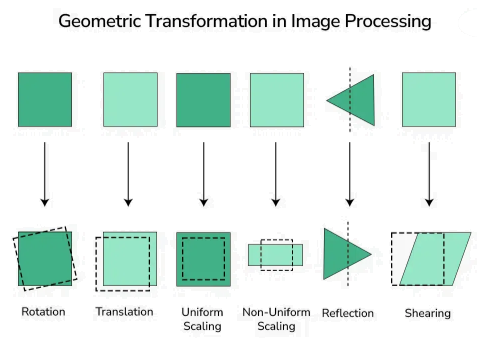
-----

### Understanding the libraries used
Before starting the lab, provide a brief definition of the following libraries and their role in image processing:

- **OpenCV**: Open Source Computer Vision Library, primarily used for image and video processing tasks such as geometric transformations, filtering, and morphological operations.
  
- **NumPy**: A fundamental package for numerical computing in Python, providing support for arrays, matrices, and mathematical functions used in image processing.
  
- **Matplotlib**: A plotting library for Python that enables visualization of images, histograms, and transformations applied to images.

If not installed, you can install them using:

`pip install opencv-python numpy matplotlib`

In [ ]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

# Manipulation 1: Geometric Transformations  

You will explore **geometric transformations** and their role in image processing, including:  

- **Resizing (Scaling)** – Adjusting the image dimensions while preserving or modifying aspect ratios.  
- **Translation** – Moving an image to a different position without altering its content.  
- **Rotation** – Changing the orientation of an image around a fixed point.  
- **Shearing** – Slanting the image along an axis, distorting its shape.  
- **Perspective Transformation** – Adjusting the image’s perspective to simulate different viewpoints.  



### Why are these transformations important?  

They are widely used in various computer vision tasks, such as:  

- **Image alignment** – Aligning images for analysis and comparison.  
- **Data augmentation** – Creating variations of images for training machine learning models.  
- **Perspective correction** – Fixing distortions in images for better representation and analysis.  

### **Theoretical research:** Provide bellow a description of the following key concepts (using your own words):


* **Geometrical transformations** : ...

* **Logical operations** : ...

* **Morphological operations** : ...


## Task 1: Image scaling  

#### **T 1.1: Resizing algorithms**  

Explore and compare different image resizing methods. For each method, provide a description of how it works:  

- **Nearest neighbor** (Simplest method, but may cause pixelation) : ...  
- **Bilinear interpolation** (Better quality, considers neighboring pixels) : ...
- **Bicubic interpolation** (Higher quality, but more computationally expensive) : ...

---

**Manual implementation of a resizing algorithm:** Write a function that implements the nearest neighbor resizing algorithm manually, without using any built-in functions for resizing. The new size can be provided as absolute values and also as positive/negative ratios.

- Load the `cameraman.png` image. 
- Resize the `cameraman.png` image both up and down using the nearest neighbor method you have implemented. Perform at leat 6 differents resizings.
- Display the original image along with its size.  
- Display the resized images with their new sizes.  

**Hint:** You can achieve this by iterating over the pixel values and mapping them to a new zero matrix (black image) with the desired size based on the chosen interpolation method. It is important to warn the user if the new size of the image does not preserve the aspect ratio (but the resize has to be performed anyway).

**Perform the same work for another resizing method: Bilinear interpolation or Bicubic interpolation.**

**Analyse the obtained images.**


In [ ]:
# Your code here.
...

Your analysis here.
...

#### **T 1.2: Image resizing using built-in functions of OpenCV**  

The `resize()` function in OpenCV allows adjusting the size of an image in different ways:  

- Scaling using axis-specific factors:  
   - `fx`: Scale factor along the **horizontal axis**.  
   - `fy`: Scale factor along the **vertical axis**.  

- Interpolation parameter (`interpolation`)  
   - Determines how pixel values are calculated when resizing.  
   - Common interpolation methods:  
     - `cv2.INTER_NEAREST`
     - `cv2.INTER_LINEAR`
     - `cv2.INTER_CUBIC`  

---

Before applying the `resize()` function, youl will first create a simple grayscale test image using `NumPy` and `Matplotlib`. The image will be **6×6 pixels** and structured as follows:  

- The background is black *(pixel value = 0)*.  
- A white square *(pixel value = 255)* fills the inner **4×4** region, starting from **row 1 and column 1**.  
- A smaller black square *(pixel value = 0)* is embedded inside the white square, occupying the **central 2×2** region.  

Once the image (`imgtest`) is created, it should be displayed before applying any resizing operations.  

After generating the test image, the next step is to apply the `resize()` function to modify its dimensions. This involves adjusting the scale factors along the horizontal (`fx`) and vertical (`fy`) axes and experimenting with different interpolation methods.  

To do this, follow these steps:  
1. Use `resize()` to scale `imgtest` by modifying the `fx` and `fy` values.  
2. Apply different interpolation methods (`INTER_NEAREST`, `INTER_LINEAR`, `INTER_CUBIC`) and observe their effects.  
3. Display both the original and resized versions of `imgtest` and analyze the differences.  


In [1]:
# Create and display the 6×6 grayscale test image, then follow the steps described above.


After experimenting with the test image, you will now apply the `resize()` function to a **real-world image**, `cameraman.png`. This will allow you to observe how resizing affects a more complex image compared to the simple structured pattern of `imgtest`.  

To analyze the effects of resizing, follow these steps:  

1. Resize `cameraman.png` by adjusting `fx` and `fy` values to scale the image both up and down.  
2. Apply a scaling factor between `0` and `1` to shrink the image while maintaining aspect ratio.  
3. Resize the image by specifying exact dimensions (`rows = 250`, `cols = 400`) instead of using scale factors.  
4. Compare the resized outputs with those from `imgtest` and discuss how interpolation affects a natural image differently from a synthetic one.  


In [ ]:
# Add your code here


### Questions:
After applying the `resize()` function to both `imgtest` and `cameraman.png`, analyze the results by answering the following questions:  

1. How does resizing a structured test image (`imgtest`) compare to resizing a real-world image (`cameraman.png`)?  
2. What differences do you observe when using different interpolation methods?  
3. How does resizing with a scaling factor (`fx`, `fy`) differ from specifying exact dimensions (`rows`, `cols`)?  
4. Which method produces the best visual quality for **upscaling** and which one for **downscaling**? Explain why.
5. Analyse this transformation considering the aspect ratio.
6. Analyze and compare the obtained resized images with those obtained using the function you implementd in **T1.1**.

---

***Add your analysis and comments here***  

...  


## Task 2: Image translation  

Geometric transformations involve mathematical operations that modify the coordinates of the image's pixels. These transformations are typically represented using transformation matrices that define how each point in the image is repositioned.  

#### **Understanding translation**  

Translation refers to shifting an image by a specified number of pixels along the **x-axis** and **y-axis**. This operation moves every pixel in the image without altering its shape, size or orientation.  

Mathematically, translation is represented as follows:  

$$
\begin{bmatrix}
x' \\ y'
\end{bmatrix}
=
\begin{bmatrix}
x + \Delta x \\ y + \Delta y
\end{bmatrix}
$$  

where:  

- \( $x'$ \) and \( $y'$ \) are the new coordinates after translation.  
- \( $x$ \) and \( $y$ \) are the original coordinates of the pixel.  
- \( $\Delta x$ \) and \( $\Delta y$ \) are the translation offsets along the horizontal and vertical axes, respectively.  

Translation is often used for **image alignment, object tracking, and perspective adjustments** in computer vision tasks.  


-------
**Exampel of translation**

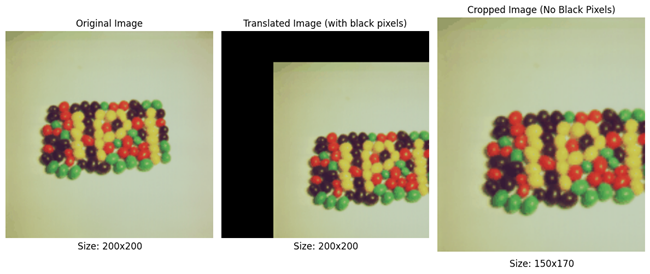


In this task, you will apply **image translation** using OpenCV's `warpAffine()` function to shift an image in different directions.  

### **Instructions:**  
1. Select an image from the given `images` folder to perform the translation.  
2. Translate the image by shifting:  
   - 100 pixels horizontally (along the x-axis).  
   - 200 pixels vertically (along the y-axis).  
   - Both axes simultaneously (100 pixels right and 200 pixels down).  
3. Remove the black pixels that appear after translation.  
4. Use the function `warpAffine()` from the `cv2` module to apply the transformation.  
5. Analyze the results by observing how translation affects the image and discussing potential use cases.  


In [ ]:
# Perform image translation as described above.


### Questions:
1. How does translating the image affect its appearance?  
2. What happens to the pixels that are shifted beyond the image boundaries?  
3. Why do black pixels appear after translation, and how can they be removed effectively?  
4. Compare translating along a **single axis ($x$ or $y$)** vs. translating along **both axes simultaneously**—what differences do you notice?
   

***Add your analysis and comments here***  

...  



#### **Challenge 1: Translating an Object**  

In this challenge, you will apply translation to animate the movement of an object inside an image.  

**Use `Circle.png` as the input image**.


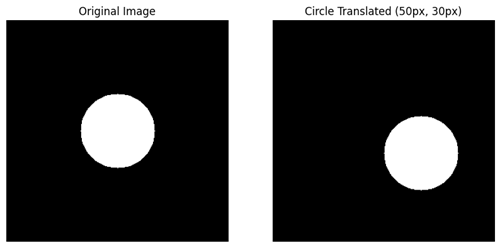

In [ ]:
# Challenge 1: Apply static translation to the image.


#### **Challenge 2: Dynamic Object Translation**  
1. Perform horizontal translation → Shift the white circle continuously to the right. Once it reaches the image boundary, it should reappear from the left side.  
2. Perform vertical translation → Shift the circle downward, ensuring it wraps around and reappears from the top.  
3. Apply sinewave-based horizontal translation → Make the circle follow a sinusoidal path as it moves horizontally.  
4. Generate an animation to visualize the movement over time.  



To create a video file, you first need to initialize a **`VideoWriter`** object.  


- Step 1: Define the codec (video format)

  `fourcc = cv2.VideoWriter_fourcc(*'mp4v')`

- Step 2: Create the video writer

  `video_writer = cv2.VideoWriter('your/saving/path/output_video.mp4', fourcc, 30, (image_width, image_height))`

- Step 3: Write frames (each frame corresponds to one translation step) to the video inside a loop

  `video_writer.write(frame)`

- Step 4: Release the video writer (finalize the video file once the loop ends)

  `video_writer.release()`

In [ ]:
# Challenge 2: Animate translation using OpenCV VideoWriter.


## Task 3: Image Rotation

Rotation is a geometric transformation that rotates an image around a fixed point (usually the center). The transformation is represented by the following mathematical formula:  

$$
\begin{bmatrix}
x' \\ y'
\end{bmatrix} =
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\ y
\end{bmatrix}
$$  

where:  
- \( $x'$ \), \( $y'$ \) are the **new coordinates** after rotation.  
- \( $x$ \), \( $y$ \) are the **original coordinates** of the pixel.  
- \( $\theta$ \) is the **rotation angle** in degrees.  
---

### **Instructions:**  
1. Choose an image from the `images` folder.
1. Write a program to rotate an image at different angles, such as **45°**, **90°**, and a full **360°** rotation.
2. Use `cv2.getRotationMatrix2D()` to generate the rotation matrix and apply it to the image.  
3. Analyze the results by observing how rotation affects the image, especially at different angles.  


In [ ]:
# Apply image rotation using cv2.getRotationMatrix2D() at different angles.


### Questions:
1. What happens to the image dimensions after rotation? Why do some rotations introduce black borders?  
2. How does OpenCV handle **out-of-frame pixels** during rotation?  


***Add your analysis and comments here***  

...  


#### **Challenge: Custom Rotation Point**  

By default, image rotation occurs around the **center of the image**. In this challenge, you will modify the transformation to **rotate an image around a custom point** instead.  

### **Instructions:**  
1. Use the same image as before or choose a different one from the `images` folder.  
2. Select a custom pivot point (e.g., a corner, an off-center point, or a specific feature in the image).  
3. Use `cv2.getRotationMatrix2D()` to compute the transformation matrix based on the chosen pivot point.  
4. Apply the rotation and display the resulting image.  
5. Analyze the difference between center-based rotation and custom-point rotation.  


In [ ]:
# Challenge: Apply rotation around custom pivot points instead of the center.


## Task 4: Affine Transformation  

Affine transformations are a class of geometric transformations that preserve **collinearity** (straight lines remain straight) and **ratios of distances** between points. They include operations such as **scaling, rotation, shearing, and translation**.  


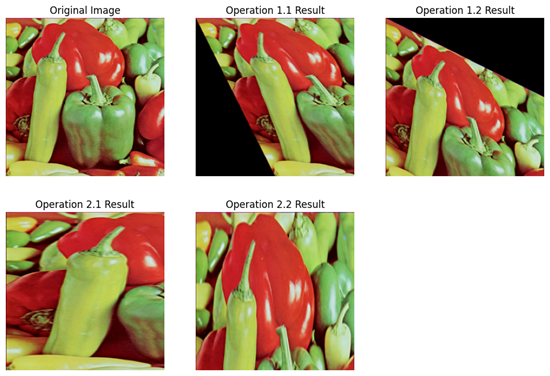

### Analysis of the Transformation:
1. Analyze the given output and determine what type of **transformation** has been applied to the `pepper.png` image.  
2. Explain the effects of the transformation and how it affects the image structure.   

***Add your analysis and comments here***  

...  


### **Instructions:**  

1. Use the appropriate OpenCV functions to **reproduce the transformations** observed in the output.  
2. Display the transformed images and compare them with the original.

In [ ]:
# Apply and reproduce the affine transformations observed in the given output.


#### **Challenge: Aligning a Tilted Image**  

In this challenge, you will correct the alignment of an image that appears **tilted or skewed**.  

- Use `leaning.jpg` from the `images` folder as the input image.  
- Apply the necessary transformations to straighten the image.  

### **Instructions:**  
1. Load `leaning.jpg` and analyze its tilt.  
2. Determine the transformation needed to correct its alignment (e.g., rotation, affine transformation, perspective correction).  
3. Use OpenCV functions such as `cv2.getRotationMatrix2D()` or `cv2.warpAffine()` to straighten the image.  
4. Display both the original and corrected images side by side for comparison.  
5. Analyze the results, explaining how alignment correction improves image perception.  


In [ ]:
# Apply transformation to align leaning.jpg.


***Add your analysis and comments here***  

...  

## Task 5: Perspective Transformation  

Perspective transformation is a geometric operation that maps an image **from one perspective** to another, commonly used for rectifying distortions or simulating different viewpoints.  

### **Instructions:**  
1. Analyze the given transformed images and identify the type of perspective transformations applied.  
2. Explain how these transformations affect the image structure, such as warping, foreshortening, or rectification.  
3. Use OpenCV functions like `cv2.getPerspectiveTransform()` and `cv2.warpPerspective()` to reproduce the transformations using the `Earth.bmp` image.  
4. Compare the transformed images with the original and discuss your observations.  


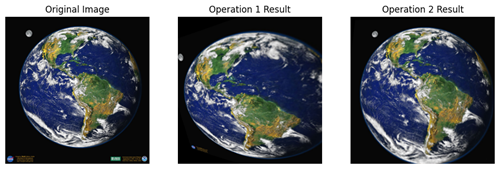

In [ ]:
# Apply perspective transformation here.


***Add your analysis and comments here***  

...  

#### **Challenge: Bird's Eye View Transformation**  

In this challenge, you will apply **geometric transformations** to align an image similar to the example shown below.  

- Use `road.png` from the `images` folder as the input image.  
- Apply the same transformation as demonstrated in the reference image below.  

![Road Alignment Example](https://journals.sagepub.com/cms/10.1177/09544070231203059/asset/images/large/10.1177_09544070231203059-fig10.jpeg)  

### **Instructions:**  
1. Apply a **perspective transformation** to align `road.png` using `cv2.getPerspectiveTransform()` and `cv2.warpPerspective()`.  
2. Apply the transformation and display the corrected image.  
3. Compare your result with the original image and the reference example.  


In [ ]:
# Apply geometric transformation to align road.png with the reference image above.


---
## Manipulation 2: Bitwise Logical Operators  

Bitwise logical operators allow us to perform **pixel-wise operations** on images. These operations are useful for **masking, blending, and extracting regions of interest** in an image.  

In OpenCV, bitwise operations are applied using `cv2.bitwise_*()` functions, which perform logical operations at the **pixel level**. Each pixel's value is modified based on the corresponding pixel values from input images, following standard **bitwise logic rules** (AND, OR, XOR, NOT).  

These operations are commonly used in **image processing** tasks, such as:  
- **Creating masks to isolate parts of an image**  
- **Combining or blending two images based on logical conditions**  
- **Extracting foreground or background elements**  



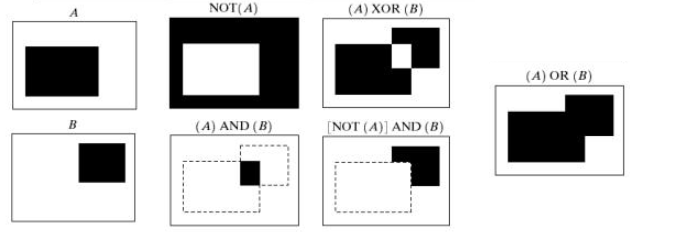
----

## Task 1: Creating and Applying Logical Operations on Binary Images  

In this task, you will generate two **binary images** and apply logical operations both **manually** and using **OpenCV functions**.  

### **Image Specifications:**  
- **Image A (256×256 pixels)** contains a **black rectangle** at coordinates **$90 ≤ x ≤ 120$** and **$90 ≤ y ≤ 180$**.  
- **Image B (256×256 pixels)** contains a **black square** at coordinates **$110 ≤ x ≤ 150$** and **$110 ≤ y ≤ 150$**.    


### **Instructions:**  

1. Create Image **A** and Image **B** using NumPy, ensuring correct pixel placements.  
2. Implement logical operations (NOT, AND, OR, XOR) manually, without using OpenCV functions.  
3. Apply logical operations using OpenCV functions:  
   - `cv2.bitwise_not()`  
   - `cv2.bitwise_and()`  
   - `cv2.bitwise_or()`  
   - `cv2.bitwise_xor()`  

4. Analyze the results, comparing the output of manual implementation with OpenCV’s built-in functions.  

In [ ]:
# Add the corresponding code here.


***Add your analysis and comments here***  

...  

## Task 2: Applying Bitwise Logical Operators on Images  

In this task, you will apply **bitwise logical operations** to different image pairs using OpenCV functions that you have previously used.


### **Instructions:**  
1. Apply the bitwise AND operation on `Brain.png` and `BrainM.png` using `cv2.bitwise_and()`.  
2. Apply the bitwise OR operation on `Brain.png` and `BrainM.png` using `cv2.bitwise_or()`.  
3. Apply the bitwise XOR operation on `Before.png` and `After.png` using `cv2.bitwise_xor()`.  
4. Apply the bitwise NOT operation separately on `QR.png` and `Jellybeans.png` using `cv2.bitwise_not()`.  
5. Display the results and analyze how each operation affects the images.  


In [ ]:
# Apply bitwise logical operations on the given image pairs using OpenCV.


***Add your analysis and comments here***  

...  